https://chatgpt.com/share/687715aa-54d0-8003-a1c0-ba5c6a3da511

In [1]:
import numpy as np
from tqdm import tqdm
import os
import pickle
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from tensorflow.keras.preprocessing.image import load_img , img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical , plot_model  #will help to see whole model in terms of image , so help to see architecture of model
from tensorflow.keras.layers import Input,Dense, LSTM, Embedding,Dropout,add
import re


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
df = pd.read_csv('flickr8k/captions.txt')

In [3]:
df.iloc[0]

image                              1000268201_693b08cb0e.jpg
caption    A child in a pink dress is climbing up a set o...
Name: 0, dtype: object

In [70]:
image_captions = df.groupby('image')['caption'].apply(list).to_dict()

In [71]:
image_captions

{'1000268201_693b08cb0e.jpg': ['A child in a pink dress is climbing up a set of stairs in an entry way .',
  'A girl going into a wooden building .',
  'A little girl climbing into a wooden playhouse .',
  'A little girl climbing the stairs to her playhouse .',
  'A little girl in a pink dress going into a wooden cabin .'],
 '1001773457_577c3a7d70.jpg': ['A black dog and a spotted dog are fighting',
  'A black dog and a tri-colored dog playing with each other on the road .',
  'A black dog and a white dog with brown spots are staring at each other in the street .',
  'Two dogs of different breeds looking at each other on the road .',
  'Two dogs on pavement moving toward each other .'],
 '1002674143_1b742ab4b8.jpg': ['A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .',
  'A little girl is sitting in front of a large painted rainbow .',
  'A small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .',
  'T

In [5]:
first_key = list(image_captions.keys())[0]
print(first_key)
print(image_captions[first_key])

1000268201_693b08cb0e.jpg
['A child in a pink dress is climbing up a set of stairs in an entry way .', 'A girl going into a wooden building .', 'A little girl climbing into a wooden playhouse .', 'A little girl climbing the stairs to her playhouse .', 'A little girl in a pink dress going into a wooden cabin .']


In [6]:
from collections import defaultdict

In [11]:
from keras.applications.resnet50 import ResNet50, preprocess_input

from keras.models import Model
from keras.layers import Input

# Load ResNet50 (exclude top layer), use second-last layer's output
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')  # ✅ This gives (2048,)
model = Model(inputs=base_model.input, outputs=base_model.output)



In [8]:
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,472 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, None,      │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, None,      │          0 │ conv2_block1_2_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, None,      │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, None,      │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, None,      │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

None


In [ ]:
# Extract features and store for all images in a dict
path = 'flickr8k/Images'

features = {}
for img_id in tqdm(image_captions.keys()):  # use your actual image ID list
    img_path = os.path.join(path, img_id)  # corrected from IMAGE_FOLDER to path
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    features[img_id] = model.predict(img_array)[0]
    


In [13]:
with open("image_features_dict.pkl", "wb") as f:
    pickle.dump(dict(features), f)

In [81]:
with open("image_features_dict.pkl", "rb") as f:
    features = pickle.load(f)

In [83]:
new_features = {}
for key, value in features.items():
    new_key = key.split('.')[0]
    new_features[new_key] = value
# Swap dictionaries
features = new_features


In [84]:
features

{'1000268201_693b08cb0e': array([0.06536566, 0.16782765, 0.32518452, ..., 0.05111523, 0.32817906,
        1.0043352 ], dtype=float32),
 '1001773457_577c3a7d70': array([0.78422934, 0.81897026, 0.06491458, ..., 0.08858151, 0.6853735 ,
        0.18749599], dtype=float32),
 '1002674143_1b742ab4b8': array([0.08419643, 0.61375225, 0.2070154 , ..., 0.        , 3.0910745 ,
        1.5620652 ], dtype=float32),
 '1003163366_44323f5815': array([0.13877572, 0.13362862, 0.21037568, ..., 0.31288373, 0.43862864,
        0.58642775], dtype=float32),
 '1007129816_e794419615': array([0.07020073, 0.46709356, 0.        , ..., 0.01412511, 0.        ,
        0.04985659], dtype=float32),
 '1007320043_627395c3d8': array([0.5258375 , 0.37079605, 0.        , ..., 0.00266838, 0.29753262,
        0.11046091], dtype=float32),
 '1009434119_febe49276a': array([0.05477907, 0.01779125, 0.17586471, ..., 0.10577034, 0.26657492,
        0.22652525], dtype=float32),
 '1012212859_01547e3f17': array([0.2661585 , 1.8070965 

In [85]:
# Choose your key (for example, the first key)
key = next(iter(features))  # gets the first key in the dict
arr = features[key]

# Convert TensorFlow tensors to NumPy arrays, if needed
if hasattr(arr, "numpy"):
    arr = arr.numpy()

# Print the key and full array
print(f"Full feature vector for key: {key}")
print(arr)           # prints all 2048 elements
print("Length:", arr.shape[0])  # confirms size is 2048


Full feature vector for key: 1000268201_693b08cb0e
[0.06536566 0.16782765 0.32518452 ... 0.05111523 0.32817906 1.0043352 ]
Length: 2048


In [86]:
df['image_id'] = df['image'].apply(lambda x: x.split('.')[0])
image_captions = df.groupby('image_id')['caption'].apply(list).to_dict()


In [87]:
list(image_captions.items())[0]

('1000268201_693b08cb0e',
 ['A child in a pink dress is climbing up a set of stairs in an entry way .',
  'A girl going into a wooden building .',
  'A little girl climbing into a wooden playhouse .',
  'A little girl climbing the stairs to her playhouse .',
  'A little girl in a pink dress going into a wooden cabin .'])

In [90]:
def clean(image_captions):
    cleaned = {}
    for key, captions in image_captions.items():
        cleaned_captions = []
        for caption in captions:
            caption = caption.lower()
            caption = re.sub(r'[^a-z\s]', '', caption)
            caption = re.sub(r'\s+', ' ', caption).strip()
            caption = ' '.join([word for word in caption.split() if len(word) > 1])
            caption = 'start ' + caption + ' end'
            cleaned_captions.append(caption)
        cleaned[key] = cleaned_captions
    return cleaned


In [91]:
processed_img_captions = clean(image_captions)

In [92]:
all_captions = []
for key in processed_img_captions:
    for caption in processed_img_captions[key]:
        all_captions.append(caption)


In [93]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1


In [94]:
#get max len of caption availabe help in padding the sequence
max_length = max(len(caption.split()) for caption in all_captions)  #Neural sequence models (like an LSTM decoder) need fixed‑length inputs. By computing you find the length of the longest caption in your dataset. You then pad all shorter sequences up to this max_length so that every training example has the same shape
max_length

34

In [95]:
img_ids = list(processed_img_captions.keys())
split = int(len(img_ids) * 0.9)
train = img_ids[:split]
test = img_ids[split:]  


In [96]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LSTM, add
import numpy as np

In [97]:
processed_img_captions

{'1000268201_693b08cb0e': ['start child in pink dress is climbing up set of stairs in an entry way end',
  'start girl going into wooden building end',
  'start little girl climbing into wooden playhouse end',
  'start little girl climbing the stairs to her playhouse end',
  'start little girl in pink dress going into wooden cabin end'],
 '1001773457_577c3a7d70': ['start black dog and spotted dog are fighting end',
  'start black dog and tricolored dog playing with each other on the road end',
  'start black dog and white dog with brown spots are staring at each other in the street end',
  'start two dogs of different breeds looking at each other on the road end',
  'start two dogs on pavement moving toward each other end'],
 '1002674143_1b742ab4b8': ['start little girl covered in paint sits in front of painted rainbow with her hands in bowl end',
  'start little girl is sitting in front of large painted rainbow end',
  'start small girl in the grass plays with fingerpaints in front of

In [ ]:


# batch_size = 32
# image_feature_dim = 2048  # ResNet50 output size

# from tensorflow.keras.preprocessing.sequence import pad_sequences
# from tensorflow.keras.utils import to_categorical

# def data_gen(data_keys, processed_img_captions, features, tokenizer, max_length, vocab_size, batch_size):
#     x1, x2, y = [], [], []
#     n = 0

#     for key in data_keys:
#         captions = processed_img_captions[key]
#         for caption in captions:
#             seq = tokenizer.texts_to_sequences([caption])[0]  #his step builds a vocabulary, assigning each word a unique integer ID., see till now i hadn't i just get all caption max_len  , vocab size
#             while 1:
#                 for key in data_keys:
#                     n+=1
#                     captions = processed_img_captions[key]
#                     for caption in captions:
#                         # seq = tokenizer.texts_to_sequences([caption[0]])
#                         for i in range(1,len(seq)):
#                             in_seq , out_seq = seq[:1],seq[i]
#                             in_seq = pad_sequences([in_seq],maxlen=max_length)[0]
#                             out_seq = to_categorical([out_seq],num_classes=vocab_size)[0]

#                             x1.append(features[key][0])  #this has representation of images got by passing through resnet
#                             x2.append(in_seq)
#                             y.append(out_seq)
#                         if n==batch_size:
#                             x1,x2,y = np.array(x1),np.array(x2),np.array(y)
#                             yield([x1,x2],y)
#                             x1,x2,y=[],[],[]

            

In [98]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LSTM, add
import numpy as np

batch_size = 32
image_feature_dim = 2048  # ResNet50 output size

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

def data_gen(data_keys, processed_img_captions, features, tokenizer, max_length, vocab_size, batch_size):
    x1, x2, y = [], [], []
    count = 0

    for key in data_keys:
        captions = processed_img_captions[key]
        for caption in captions:
            seq = tokenizer.texts_to_sequences([caption])[0]
            for i in range(1, len(seq)):
                in_seq, out_token = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_token], num_classes=vocab_size)[0]

                x1.append(features[key])  # image features
                x2.append(in_seq)         # input sequence
                y.append(out_seq)         # output word (one-hot)
                count += 1

                if count == batch_size:
                    yield (np.array(x1, dtype=np.float32),
                           np.array(x2, dtype=np.int32)), \
                          np.array(y, dtype=np.float32)
                    x1, x2, y, count = [], [], [], 0


In [99]:
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, LSTM, add
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

#these are layers

# Image feature branch
inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# Sequence (caption) branch
inputs2 = Input(shape=(max_length,))  #this is that we will take input of this lenght
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
#The first parameter, vocab_size, defines the number of unique tokens your model recognizes.

# The 256 is the embedding dimension — the size of the vector representing each token.
# Embedding(vocab_size, 256, mask_zero=True) jere we right now passing all tokens give (batch_size, max_length, 256) token size 256 size vectoer
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# Combine branches
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['categorical_accuracy']
)

# plot_model(model, show_shapes=True)


In [135]:
epochs = 50
batch_size=32
steps = len(train)//batch_size #after this do back_pro. and fetch new data

for i in tqdm(range(epochs)):
    generator = data_gen(train,processed_img_captions,features, tokenizer,max_length,vocab_size,batch_size)
    model.fit(generator,epochs=1,steps_per_epoch=steps,verbose=1) #gene.. will give inputs  #verbose wont show val__acc as we dont have val gen

  0%|          | 0/50 [00:00<?, ?it/s]

227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - categorical_accuracy: 0.9034 - loss: 0.2193


  2%|▏         | 1/50 [00:10<08:26, 10.34s/it]

227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - categorical_accuracy: 0.8628 - loss: 0.3829


  4%|▍         | 2/50 [00:19<07:48,  9.75s/it]

...

 96%|█████████▌| 48/50 [07:19<00:20, 10.18s/it]

227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - categorical_accuracy: 0.9079 - loss: 0.2227


 98%|█████████▊| 49/50 [07:29<00:10, 10.15s/it]

227/227 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - categorical_accuracy: 0.9055 - loss: 0.2150


100%|██████████| 50/50 [07:40<00:00,  9.21s/it]


In [130]:
model.save("image_caption_model.h5")

In [ ]:
# from tensorflow.keras.models import load_model
# model = load_model("image_caption_model.h5")

In [136]:
def idx_to_word(integer,tokenizer): #convert id to word
    for word , index in tokenizer.word_index.items(): #? what it is here
        if index == integer:
            return word
    return None

In [137]:
#generate caption for image
def predict_caption(model,image,tokenizer,max_length):
    #add start tag for generation prcess
    in_text = 'start'
    #iterate over max_lenth of sequence
    for i in range(max_length):
        image = np.random.rand(2048) 
        sequence = tokenizer.texts_to_sequences([in_text])[0] #?  #why we hadn't take already made token of <start>
        sequence = pad_sequences([sequence],maxlen=max_length)
        #Predict next word
        image = image.reshape((1, -1))   
        sequence = sequence.reshape((1, max_length))
        yhat = model.predict([image,sequence],verbose=0)
        #see we will probab of 8000 word , will take word with max probab
        yhat = np.argmax(yhat)
        #convert index to word
        word = idx_to_word(yhat,tokenizer)
        #stop if word is none
        if word is None:
            break
        in_text += ' ' + word
        if word== 'end':
            break
    
    return in_text
            


In [138]:
from nltk.translate.bleu_score import corpus_bleu
actual , predicted = [] , []
for key in tqdm(test):
    #actual caption
    caption = processed_img_captions[key]
    #predict caption for image
    y_pred = predict_caption(model,features[key],tokenizer,max_length)
    actual_captions = [captions.split() for captions in caption]
    y_pred = y_pred.split()

    #see we spiltting as we compare words only to measure accuracy
    actual.append(actual_captions)
    predicted.append(y_pred)#? tell list of list here
#calculate bleu score  see we use it when we deal with text data , it will have n-gram scores
print('BLEU-1: %f'  % corpus_bleu(actual , predicted , weights=(1.0,0,0,0)))  #? this score
print('BLEU-2: %f'  % corpus_bleu(actual , predicted , weights=(0.5,0.5,0,0)))

# BLEU-1 (unigram precision): measures overlap of individual words.

# BLEU-2 (bigram precision): measures overlap of pairs of consecutive words.

100%|██████████| 810/810 [05:13<00:00,  2.59it/s]

BLEU-1: 0.334831
BLEU-2: 0.123966


In [139]:
#visualizing image and caption(results)
from PIL import Image
import matplotlib.pyplot as plt
def generate_caption(image_name):
    image_id = image_name.split('.')[0]
    path = 'flickr8k/Images'
    img_path = os.path.join(path,image_name )
    image = Image.open(img_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()
    captions = processed_img_captions[image_id]
    print('---------------Actual---------')
    for caption in captions:
        print(caption)  
    y_pred = predict_caption(model,features[image_id],tokenizer,max_length)
    print('---------predicted--------') 
    print(y_pred)


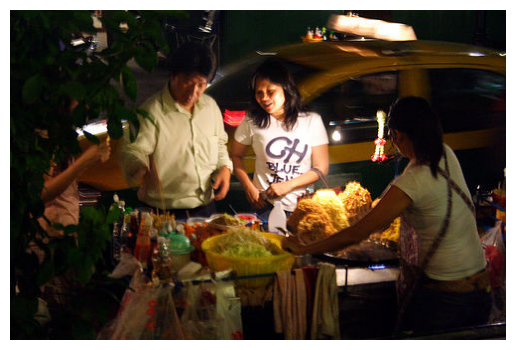

---------------Actual---------
start young couple inspect merchandise from street vendor end
start people are gathering around table of food and outside taxi wisks by end
start three people prepare table full of food with police car in the background end
start two people look at street vendor end
start two women and man at food counter in dim lights end
---------predicted--------
start young boy is sitting next to water while the water on the water end


In [140]:
generate_caption('33108590_d685bfe51c.jpg')